In [1]:

dataset_name = 'residential'
dataset_name_m ='Residential'  # Current dataset name
curr_data = "BR_Residential"  # Current data folder name

In [2]:
import sys
sys.path.append('../')
from model.VQAE import VQAE
from model.MARL import MARL
from utils import device, add_noise
from tqdm import tqdm
import torch
from data.FloorPlanLoader import *
import torch.nn.functional as F
import random
import json
import torchvision
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

USE_MULTISCALE = True
USE_MULTITASK = True

#Reproducability Checks:
random.seed(0) #Python
torch.manual_seed(0) #Torch
np.random.seed(0) #NumPy


import torchvision
import torchvision.transforms.functional as TF
import imageio
from torchvision.utils import save_image
# %load_ext autoreload
# %autoreload 2
import csv
import numpy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from umap import UMAP
import matplotlib.pyplot as plt
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'

In [3]:
#Hyperparameter
batch_size = 128
n_hiddens = 32
n_residual_hiddens = 32
n_residual_layers = 1
embedding_dim = 64
n_embeddings = 256
beta = .25
lr = 1e-3
epochs = 100
noise=False
noise_weight=0.05
img_channel=3 if USE_MULTISCALE else 1

### prepare latent.pt file

In [4]:
#Load Dataset

floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_br/{dataset_name}/',\
                         data_config=f'../data/data_config_1/residential/{dataset_name_m}/', preprocess=True)
data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)
vqae = VQAE(n_hiddens, n_residual_hiddens, n_residual_layers,
            n_embeddings, embedding_dim, 
            beta, img_channel).to(device)

marl = MARL(vqae, True, floor.age_label_num, floor.category_num, floor.num_second_use).to(device)
checkpoint = torch.load(f"../checkpoint/best_{dataset_name}.pt", map_location=device)
marl.load_state_dict(checkpoint["model_state_dict"])
# print(f"data shape: {floor[0]['image_tensor'].shape}, dataset size: {len(floor)}")
for param in vqae.parameters():
    param.to('cpu')
for param in marl.parameters():
    param.to('cpu')

marl.eval()
latents = None
with torch.no_grad():
    for data in tqdm(data_loader):
        data = data['image_tensor'].to(device)
        valid_recon = marl(data)
        quantized = valid_recon['latent']
        if latents is not None:
            latents = torch.cat([latents, quantized], dim=0)
        else: 
            latents = quantized
latent_file_path = f'../data/data_root/marl_latent_{curr_data}.pt'
print(f"finished latents configuration, now saving to {latent_file_path} ...")
torch.save(latents, latent_file_path)
print(f"latent saved to {latent_file_path} ...")

100%|██████████| 175/175 [02:15<00:00,  1.29it/s]


finished latents configuration, now saving to ../data/data_root/marl_latent_BR_Residential.pt ...
latent saved to ../data/data_root/marl_latent_BR_Residential.pt ...


# Embedding Space Visualization
## Visualize the latent with UMAP and T-SNE

In [5]:
latent_file_path = f'../data/data_root/marl_latent_{curr_data}.pt'
latents = torch.load(latent_file_path)
floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_br/{dataset_name}/',\
                         data_config=f'../data/data_config_1/residential/{dataset_name_m}/', preprocess=True)
data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)

In [6]:
#latent_file_path = f'../data/data_br/{dataset_name}/'
#pt_files = [f for f in os.listdir(latent_file_path) if f.endswith('.pt')]

# Load each file into a list
#latents = [torch.load(os.path.join(latent_file_path, f)) for f in pt_files]
#floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_br/{dataset_name}/',\
#                         data_config=f'../data/data_config_1/residential/{dataset_name_m}/', preprocess=True)
#data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)


/opt/anaconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


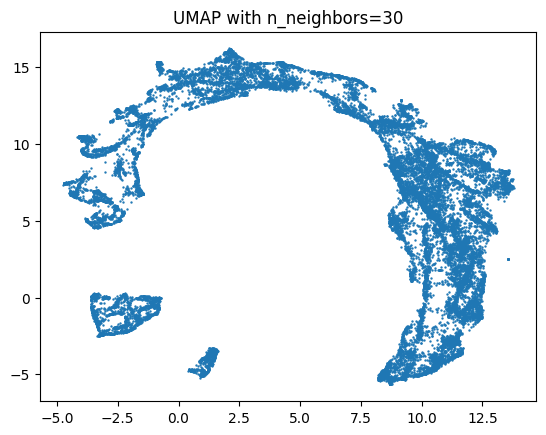

/opt/anaconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


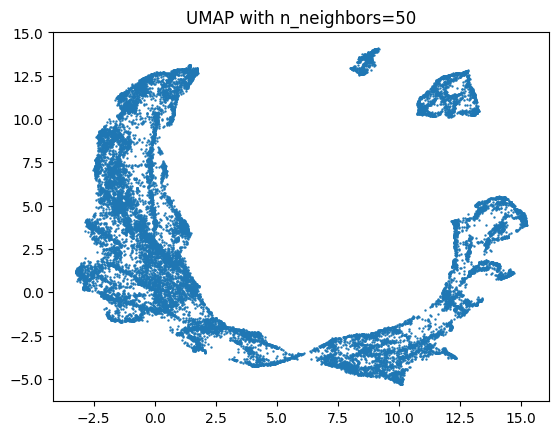

In [7]:

#latents = torch.stack(latents)  # assuming latents is a list of tensors

neighbors_list = [30,50]

for n_neighbors in neighbors_list:
    umap = UMAP(n_neighbors=n_neighbors, n_components=2, random_state=42)
    data_2d_umap = umap.fit_transform(torch.flatten(latents, start_dim=1).cpu())

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(data_2d_umap[:, 0], data_2d_umap[:, 1], s=0.5)
    ax.set_title(f'UMAP with n_neighbors={n_neighbors}')
    plt.show()





/opt/anaconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


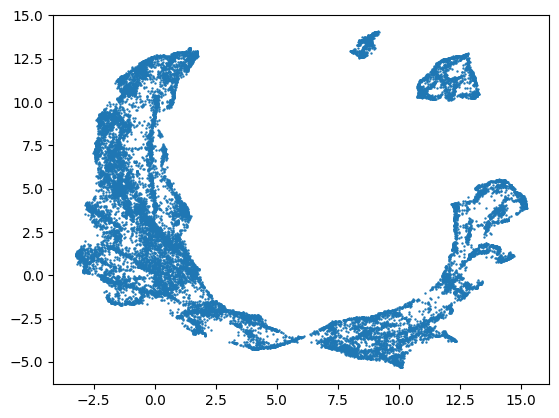

In [8]:
umap = UMAP(n_neighbors =50, n_components=2, random_state=42)
data_2d_umap = umap.fit_transform(torch.flatten(latents, start_dim=1).cpu())
# Create a figure and a 3D axes object
fig = plt.figure()
ax = fig.add_subplot(111)

# Create the initial scatter plot
ax.scatter(data_2d_umap[:, 0], data_2d_umap[:, 1], s=0.5)

# Show the plot
plt.show()

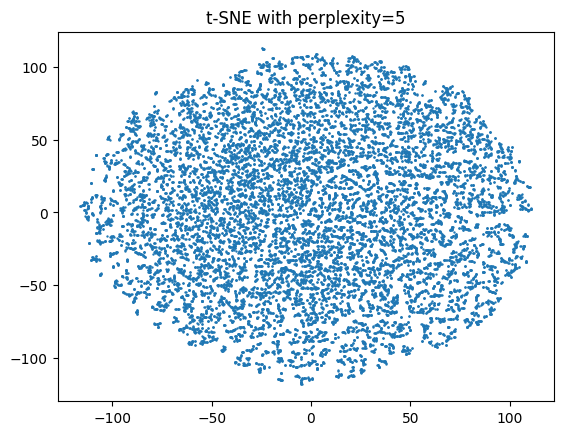

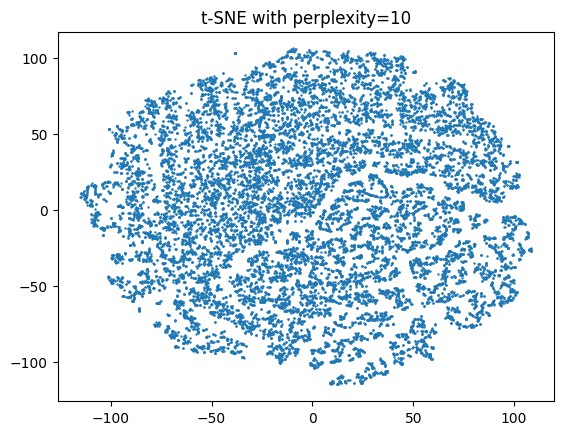

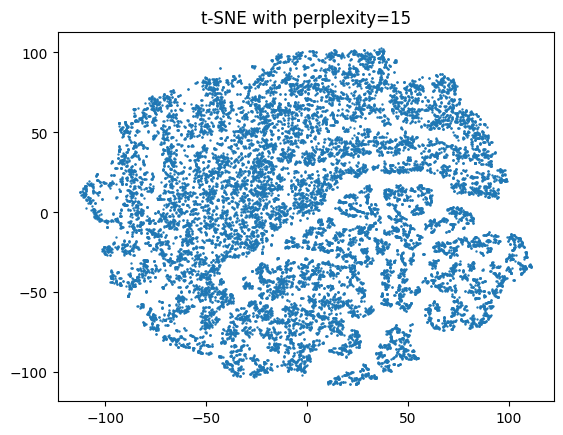

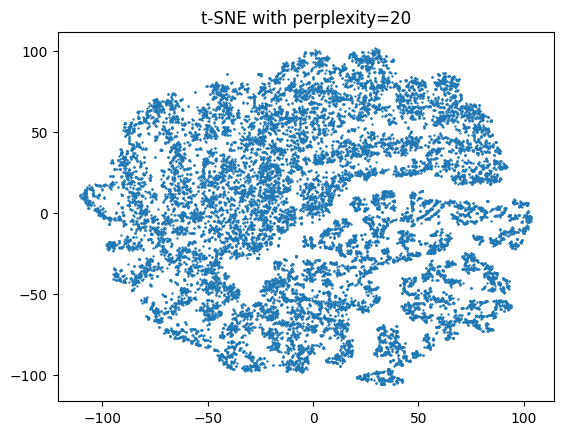

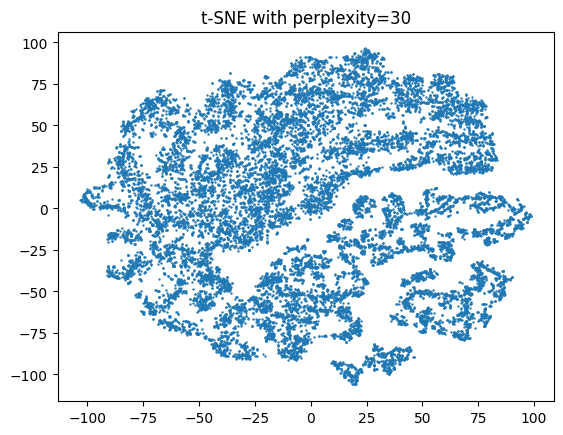

In [9]:


perplexities = [5,10,15,20, 30]

for perplexity in perplexities:
    tsne = TSNE(n_components=2, perplexity=perplexity, init='pca', random_state=42)
    data_2d_tsne = tsne.fit_transform(torch.flatten(latents, start_dim=1).cpu())

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(data_2d_tsne[:, 0], data_2d_tsne[:, 1], s=0.5)
    ax.set_title(f't-SNE with perplexity={perplexity}')
    plt.show()

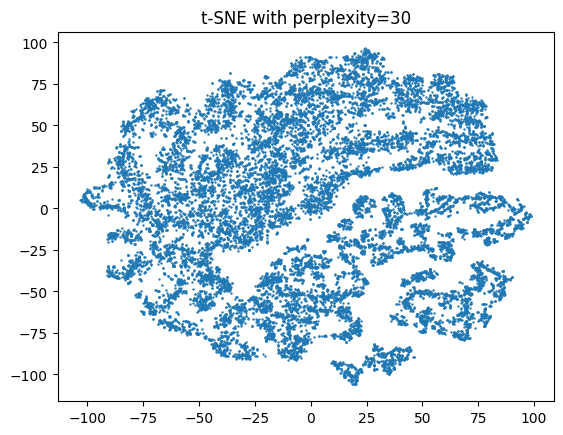

In [10]:
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
data_2d_tsne = tsne.fit_transform(torch.flatten(latents, start_dim=1).cpu())

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(data_2d_tsne[:, 0], data_2d_tsne[:, 1], s=0.5)
ax.set_title(f't-SNE with perplexity=30')
save_path = f"../notebooks/{dataset_name}/tsne_perp30.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### deciding the number of clusters

In [11]:
def calculate_wcss(latents):
    wcss = []
    for n in tqdm(range(1, 7)):  # change the range according to your needs
        kmeans = KMeans(n_clusters=n)
        data = torch.flatten(latents, start_dim=1).cpu()
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)  # inertia_ is the WCSS for the model
    return wcss
# calculate WCSS for different numbers of clusters
wcss = calculate_wcss(latents)

100%|██████████| 6/6 [01:10<00:00, 11.67s/it]


In [12]:
# Convert list to DataFrame
wcss_df = pd.DataFrame(wcss)
wcss_df.to_csv(f'wcss_{curr_data}.csv',index=False)
wcss_df

,0
0,8.946635e+08
1,8.003944e+08
2,7.524084e+08
3,7.093351e+08
4,6.756949e+08
5,6.571807e+08


In [13]:
def plot_elbow(wcss, filename=None):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(wcss) + 1), wcss, 'bo-')
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.grid()
    filename = f'../notebooks/{dataset_name}/elbow_plot_kmeans.png' 
    plt.savefig(filename)

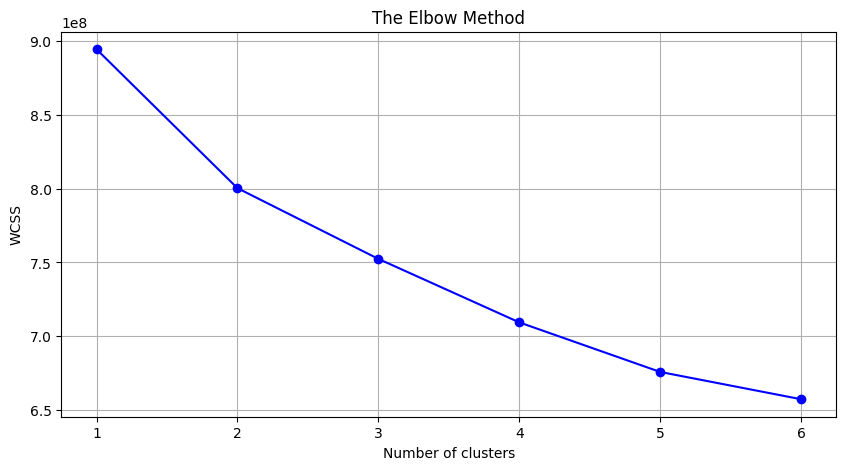

In [14]:
# plot the elbow graph
plot_elbow(wcss)

the number of clusters are set to 5, 10, 15

In [15]:
def calculate_slope(points):
    slopes = []
    for i in range(len(points) - 1):
        slope = (points[i + 1] - points[i]) / (i + 2 - i)
        slopes.append(slope)
    return slopes

def find_optimal_point(slopes, drop_threshold=0.1):
    optimal_point = 1
    for i in range(len(slopes)):
        if slopes[i] / slopes[i - 1] <= drop_threshold:
            optimal_point = i + 1
            break
    return optimal_point

In [16]:
# Calculate slopes
slopes = calculate_slope(wcss)
print(slopes)
# Find the optimal point based on the slope
optimal_point = find_optimal_point(slopes)

print("Optimal point:", optimal_point)

[-47134558.56524533, -23992999.04818344, -21536644.681005955, -16820122.675436497, -9257107.097196877]
Optimal point: 1


Slope plot saved to ../notebooks/residential/slope_plot.png


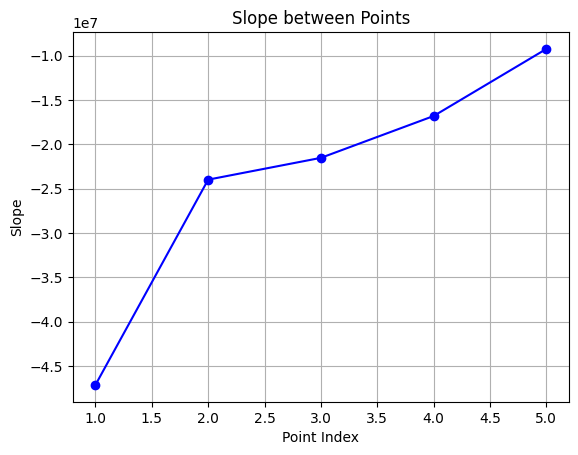

In [17]:
# Plot the slopes
plt.plot(range(1, len(wcss)), slopes, 'bo-')
plt.title('Slope between Points')
plt.xlabel('Point Index')
plt.ylabel('Slope')
plt.grid()
save_path = f"../notebooks/{dataset_name}/slope_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Slope plot saved to {save_path}")
plt.show()

In [18]:
from kneed import KneeLocator
log_file = "silhouette_scores.txt"
K = range(1, len(wcss) + 1)
kneedle = KneeLocator(K, wcss, curve='convex', direction='decreasing')
print("Optimal number of clusters:", kneedle.knee)
print(wcss)
with open(log_file, "a") as f:  # "a" = append mode
    f.write(f"\n--- {dataset_name_m} ---\n")
    msg_w = f"elbow k={kneedle.knee}\n"
    print(msg_w.strip())  # still show in terminal
    f.write(msg_w)


Optimal number of clusters: None
[894663532.7149698, 800394415.5844791, 752408417.4881122, 709335128.1261003, 675694882.7752273, 657180668.5808336]
elbow k=None


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import torch

# Flatten your latent vectors for clustering
data = torch.flatten(latents, start_dim=1).cpu().numpy()



best_score = -1
optimal_k = 2 

with open(log_file, "a") as f:
    f.write(f"\n--- {dataset_name_m} ---\n")

    for k in range(2, 10):  # try k=2 to 6
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)
        score = silhouette_score(data, labels)
        msg = f"k={k}, silhouette score={score:.4f}\n"
        print(msg.strip())
        f.write(msg)
        if score > best_score:
            best_score = score
            optimal_k = k

    f.write(f"Optimal number of clusters (silhouette): {optimal_k}\n")

k=2, silhouette score=0.1081
k=3, silhouette score=0.0965
k=4, silhouette score=0.0910
k=5, silhouette score=0.0996
k=6, silhouette score=0.1094
k=7, silhouette score=0.1127
k=8, silhouette score=0.1055
k=9, silhouette score=0.1113


### Clustering

In [20]:

n_clusters = optimal_k 
data_latent = latents # this is the data for clustering
print(n_clusters)

7


In [21]:
#Initialize the class object
kmeans = KMeans(n_clusters=n_clusters)
data = torch.flatten(data_latent, start_dim=1).cpu()
# #predict the labels of clusters.
label = kmeans.fit_predict(data)
# get cluster centers
cluster_centers = kmeans.cluster_centers_
closest, _ = pairwise_distances_argmin_min(cluster_centers, data)
print(cluster_centers.shape, data.shape)



center_list = closest
print(center_list)
df = np.stack((label, floor.all_data_dirs)).transpose()
df = pd.DataFrame(df,columns=['label','data'])

(7, 25088) torch.Size([22306, 25088])
[11279   901 13536 12892 18197  8092 18453]


In [22]:
def calculate_index_png(index):
    image_path = floor.all_data_dirs[index]  # Replace with appropriate image paths list
    file_name, file_extension = os.path.splitext(image_path)
    num_index = os.path.basename(file_name)
    return num_index

In [23]:
# Save closest points and cluster centers to CSV
df_center = pd.DataFrame({'Cluster Center': cluster_centers.tolist(), 'Closest Point Index': closest})
df_center['index_png'] = df_center['Closest Point Index'].apply(lambda x: calculate_index_png(x))
df_center.to_csv(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_{n_clusters}cluster_centers.csv', index=False)

df_center_index = np.stack((label, floor.all_data_dirs)).transpose()
df_center_index = pd.DataFrame(df_center_index,columns=['label','data'])
df_center_index['index'] = df_center_index['data'].str.extract(r'(\d+).pt')
df_center_index = df_center_index.drop(['data'], axis=1)
df_center_index = df_center_index.dropna(subset=['index'])
df_center_index['index'] = df_center_index['index'].astype(int)
df_center_index.to_csv(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_{n_clusters}clusters_clusterindex.csv', index=False)
print(df_center_index.shape)
df_center_index.head(10)


(22306, 2)


,label,index
0,3,5114
1,5,17137
2,3,10854
3,3,7011
4,1,15032
5,2,12951
6,5,18349
7,2,20333
8,3,34821
9,4,22236


In [24]:
center_list = closest
center_list_annotation = df_center['index_png'].tolist()

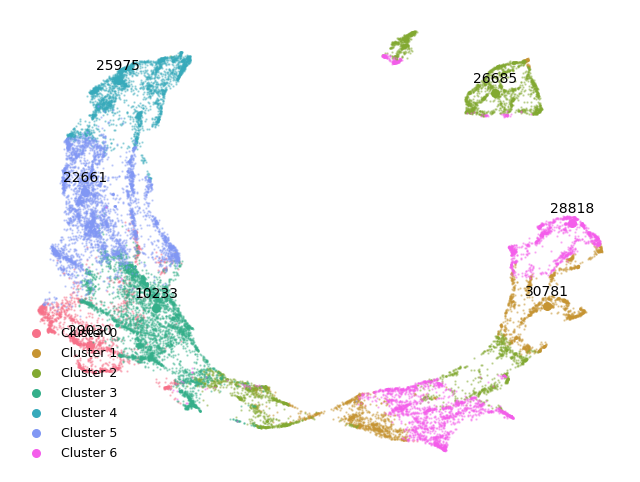

In [25]:
data_2d = data_2d_umap # this is the data for visualization
dim_name = 'umap'

#Getting unique labels
plt.figure(figsize=(8,6))
u_labels = np.unique(label)
num_labels = len(u_labels)
color_palette = sns.color_palette('husl', num_labels)
for i, each in enumerate(center_list):
    plt.scatter(data_2d[each][0],data_2d[each][1], s=30, c=[color_palette[i]])
    plt.annotate(center_list_annotation[i], (data_2d[each][0],data_2d[each][1]), ha="center", va="center", xytext=(0,10), textcoords='offset points')
for i in u_labels:
    plt.scatter(data_2d[label == i , 0] , data_2d[label == i , 1] , label=f"Cluster {i}", s=0.5, c=[color_palette[i]],alpha=0.4)
legend = plt.legend(loc='lower left', ncol=1, frameon=False)
for legend_handle in legend.legend_handles:
    legend_handle.set_sizes([30])  # Increase the size of legend dots    
    legend_handle.set_alpha(1)
plt.setp(legend.texts, fontsize='9')
plt.axis('off')
plt.savefig(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_{dim_name}_{n_clusters}_kmeans.png')

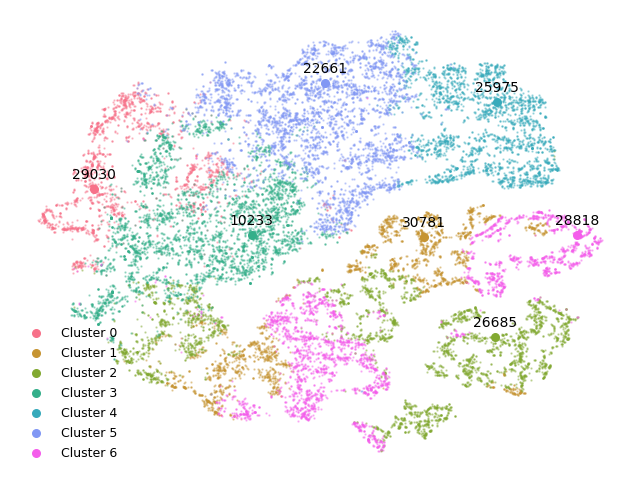

In [26]:
data_2d = data_2d_tsne # this is the data for visualization
dim_name = 'tsne'

#Getting unique labels
plt.figure(figsize=(8,6))
u_labels = np.unique(label)
num_labels = len(u_labels)
color_palette = sns.color_palette('husl', num_labels)
for i, each in enumerate(center_list):
    plt.scatter(data_2d[each][0],data_2d[each][1], s=30, c=[color_palette[i]])
    plt.annotate(center_list_annotation[i], (data_2d[each][0],data_2d[each][1]), ha="center", va="center", xytext=(0,10), textcoords='offset points')
for i in u_labels:
    plt.scatter(data_2d[label == i , 0] , data_2d[label == i , 1] , label=f"Cluster {i}", s=0.5, c=[color_palette[i]],alpha=0.4)
legend = plt.legend(loc='lower left', ncol=1, frameon=False)
for legend_handle in legend.legend_handles:
    legend_handle.set_sizes([30])  # Increase the size of legend dots 
    legend_handle.set_alpha(1)
plt.setp(legend.texts, fontsize='9')
plt.axis('off')
plt.savefig(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_{dim_name}_{n_clusters}_kmeans.png')

## Visualize the cluster center

In [27]:
def scale_crop(img): #B,C,H,W
    rescale = transforms.Compose([transforms.Resize(112),
                                  transforms.CenterCrop(56)])
    return rescale(img)

In [28]:
indexes = center_list
cluster_count = n_clusters
print(f"Number of clusters: {cluster_count}, Number of indexes: {len(indexes)}")

Number of clusters: 7, Number of indexes: 7


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09085677..0.49995008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49995002..0.49995008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49995002..0.49995008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08753677..0.49995008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49995002..0.49995008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49995002..0.49995008].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got rang

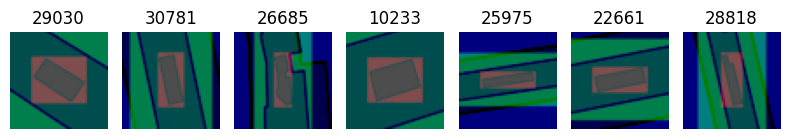

In [29]:
# Create a figure and axes with `cluster_count` subplots
fig, axes = plt.subplots(1, cluster_count, figsize=(8, 3))
image_size = 112
crop_size = 56

# Iterate over the `cluster_count` subplots
for i, index in enumerate(indexes):
    image_path = floor.all_data_dirs[index]
    # Read the image using torch's load
    image = torch.load(image_path)
    scaled = scale_crop(image)
    # Display the image in the corresponding subplot
    image_array = scaled.permute(1, 2, 0).numpy()  # Convert to (56, 56, 3) shape
    axes[i].imshow(image_array, cmap='gray')
    axes[i].set_title(os.path.basename(image_path).split(".")[0])
    axes[i].axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Save the plot
plt.savefig(f"../results/recon_img/{dataset_name}/MARL_{curr_data}_{cluster_count}cluster_sample_multiscale.png")

In [30]:
def get_zoomed_img(image_path, half_pixel):
    image = mpimg.imread(image_path)
    # Get the center coordinates
    height, width, _ = image.shape
    center_x = width // 2
    center_y = height // 2
    
    # Calculate the coordinates for the center 150x150 pixels
    x1 = center_x - half_pixel
    x2 = center_x + half_pixel
    y1 = center_y - half_pixel
    y2 = center_y + half_pixel
    
    # Extract the center 150x150 pixels from each image
    center_img = image[y1:y2, x1:x2]
    return center_img

[29030, 30781, 26685, 10233, 25975, 22661, 28818]

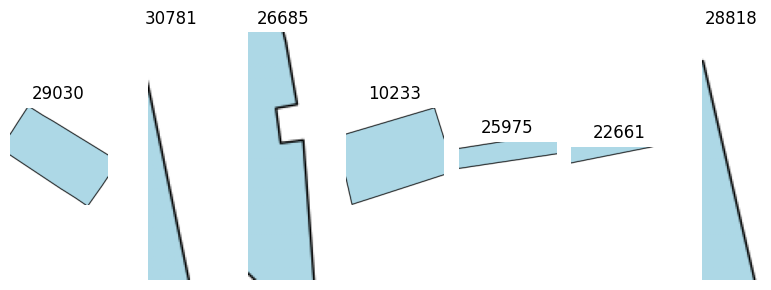

In [31]:
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

cluster_count = n_clusters
# Create a figure and axes with `cluster_count` subplots
fig, axes = plt.subplots(1, cluster_count, figsize=(8, 3))
image_size = 112
crop_size = 56
new_dir = dataset_name
num_indexes = []

if not os.path.exists(new_dir):
    os.makedirs(new_dir)

for i, index in enumerate(indexes):
    image_path = floor.all_data_dirs[index]
    # Split the path into the name and the extension
    file_name, file_extension = os.path.splitext(image_path)
    # Replace the '.pt' extension with '.png'
    png_file_path = file_name + '.png'
    # Read the image data
    img = get_zoomed_img(png_file_path, 75)
    # Display the image in the corresponding subplot
    axes[i].imshow(img, cmap='gray')
    # Extract numerical part from the file name
    num_index = int(os.path.basename(file_name))
    num_indexes.append(num_index)
    axes[i].set_title(f"{num_index}")
    axes[i].axis('off')

    # Add the prefix 'VQVAE_' to the original filename
    basename = os.path.basename(file_name)
    # Add the prefix 'VQVAE_' to the basename
    new_basename = f'MARL_{curr_data}_{basename}.png'
    # Copy the PNG file to the new directory with the modified filename
    shutil.copy(png_file_path, os.path.join(new_dir, new_basename))

# Adjust the spacing between subplots
plt.tight_layout()

# Save the plot
plt.savefig(f"../results/recon_img/{dataset_name}/MARL_{curr_data}_{cluster_count}cluster_sample.png")
num_indexes

In [32]:
import numpy as np
from collections import Counter
import pandas as pd

# `label` is your kmeans labels (shape [N])
# get true second_use labels from dataset
true_labels = np.array([floor[i]['second_use_label'] for i in range(len(floor))]).astype(int)

# contingency
clusters = np.unique(label)
rows = []
for c in clusters:
    idx = np.where(label == c)[0]
    counts = Counter(true_labels[idx])
    total = len(idx)
    top_label, top_count = counts.most_common(1)[0]
    purity = top_count / total
    rows.append({'cluster': int(c), 'size': total, 'top_label': int(top_label), 'top_count': int(top_count), 'purity': purity, 'counts': dict(counts)})

pd.DataFrame(rows).sort_values('cluster')


,cluster,size,top_label,top_count,purity,counts
0,0,1866,33,1865,0.999464,"{33: 1865, 60: 1}"
1,1,2412,33,2407,0.997927,"{33: 2407, 60: 5}"
2,2,3764,33,3763,0.999734,"{33: 3763, 60: 1}"
3,3,4084,33,4077,0.998286,"{33: 4077, 60: 7}"
4,4,2780,33,2777,0.998921,"{33: 2777, 60: 3}"
5,5,4193,33,4189,0.999046,"{33: 4189, 60: 4}"
6,6,3207,33,3206,0.999688,"{33: 3206, 60: 1}"


In [33]:
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

cluster_count = n_clusters
image_size = 112
crop_size = 56


num_indexes = []

# Create the output directory if it doesn't exist
if not os.path.exists(new_dir):
    os.makedirs(new_dir)

# Loop over each image and save it separately
for i, index in enumerate(indexes):
    image_path = floor.all_data_dirs[index]
    file_name, _ = os.path.splitext(image_path)
    png_file_path = file_name + '.png'

    # Load and process the image
    img = get_zoomed_img(png_file_path, 75)

    # Extract a short name or ID
    num_index = os.path.basename(file_name)
    num_indexes.append(num_index)

    # Compose new filename with prefix
    new_basename = f'MARL_{curr_data}_{index}.png'
    output_path = os.path.join(new_dir, new_basename)

    # Save the image (cmap='gray' is optional for grayscale)
    plt.imsave(output_path, img, cmap='gray')

print(f"Saved {len(indexes)} individual images to '{new_dir}/'")

num_indexes



Saved 7 individual images to 'residential/'


['29030', '30781', '26685', '10233', '25975', '22661', '28818']

In [34]:
indexes = num_indexes
indexes

['29030', '30781', '26685', '10233', '25975', '22661', '28818']

#Distribution of clusters

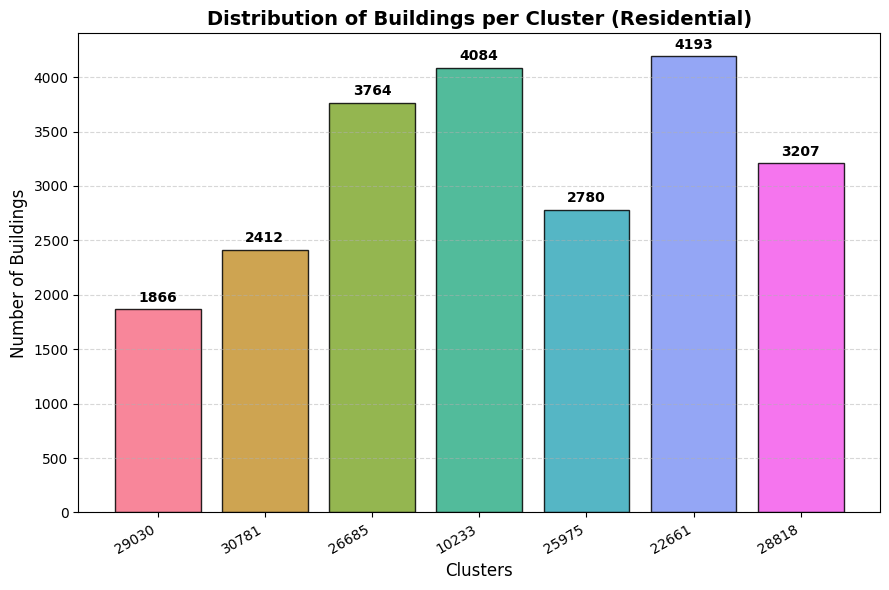

In [35]:
unique_labels, counts = np.unique(label, return_counts=True)
cluster_labels = [center_list_annotation[i] for i in unique_labels]
bar_colors = [color_palette[i] for i in unique_labels]

plt.figure(figsize=(9, 6))
bars = plt.bar(cluster_labels, counts, color=bar_colors, edgecolor="black", alpha=0.85)
plt.title(f"Distribution of Buildings per Cluster ({dataset_name_m})", fontsize=14, weight="bold")
plt.xlabel("Clusters", fontsize=12)
plt.ylabel("Number of Buildings", fontsize=12)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             str(count), ha='center', va='bottom', fontsize=10, weight="bold")
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"../results/recon_img/{dataset_name}/MARL_{curr_data}_{n_clusters}_commercial_cluster_distribution.png", dpi=300)
plt.show()

In [36]:
metadata_df = pd.read_csv(f"../data/data_config_1/residential/{dataset_name_m}/meta_trsa_{dataset_name_m}.csv")

In [37]:
# Get cluster center indices (from your clustering code)
center_indices = [int(idx) for idx in num_indexes]  # num_indexes from your code

# Filter metadata for cluster centers
selected = metadata_df[metadata_df['OBJECTID'].isin(center_indices)].copy()
selected['orientation'] = selected['orientation'] * 355.0
selected['street_width'] = selected['street_width'] * 149.58

# Select columns and print in LaTeX format
cols = ['OBJECTID', 'YearBuilt1', 'HEIGHT', 'UseDescription', 'orientation', 'street_width', 'second_type']
output_file = "latex_table.txt"
with open(output_file, "a") as f:  # "a" = append mode
    f.write(f"\n--- {dataset_name_m} ---\n") 
    for _, row in selected[cols].iterrows():
        line = (
            f"{int(row['OBJECTID'])} & "
            f"{row['YearBuilt1']} & "
            f"{row['HEIGHT']} & "
            f"{int(row['UseDescription'])} & "
            f"{row['orientation']:.2f} & "
            f"{row['street_width']:.2f} & "
            f"{int(row['second_type'])} \\\\\n"
        )
        print(line.strip())  # still print to terminal
        f.write(line)

10233 & 1928.0 & 6.0 & 1 & 75.00 & 9.98 & 33 \\
22661 & 1932.0 & 3.0 & 1 & 80.00 & 99.68 & 33 \\
25975 & 1960.0 & 3.0 & 1 & 260.00 & 9.84 & 33 \\
26685 & 1999.0 & 18.0 & 1 & 260.00 & 42.91 & 33 \\
28818 & 1952.0 & 6.0 & 1 & 160.00 & 10.15 & 33 \\
29030 & 1936.0 & 9.0 & 1 & 300.00 & 19.88 & 33 \\
30781 & 1972.0 & 3.0 & 1 & 345.00 & 9.71 & 33 \\


## calculate aggregated area

In [38]:

merged_df = pd.merge(df_center_index, metadata_df, left_on='index', right_on = 'OBJECTID', how='inner')
print(df_center_index.shape, merged_df.shape)
merged_df
merged_df.to_csv(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_{n_clusters}clusters_full_metadata.csv', index=False)

(22306, 2) (22306, 9)


k=2, silhouette score=0.1081
k=3, silhouette score=0.0965
k=4, silhouette score=0.0910
k=5, silhouette score=0.0996
k=6, silhouette score=0.1094
k=7, silhouette score=0.1127
Optimal k (multimodal): 7


/opt/anaconda3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


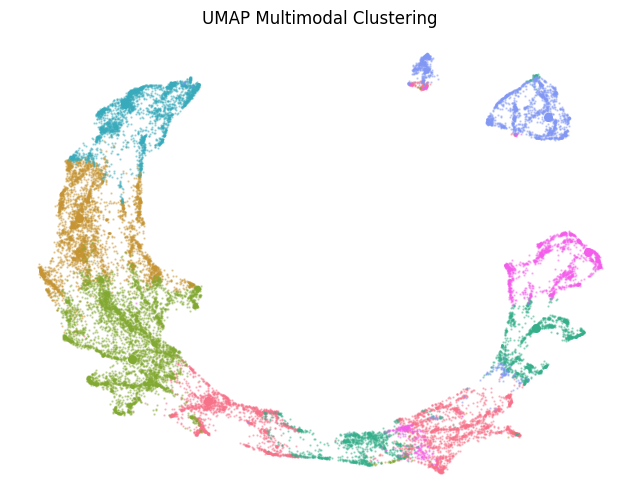

Multimodal cluster centers (indices): [  199  8092 17250 12265 18197  3056  4474]
Corresponding file paths / IDs:
Index 199 -> ../data/data_br/residential/26959.pt
Index 8092 -> ../data/data_br/residential/22661.pt
Index 17250 -> ../data/data_br/residential/3063.pt
Index 12265 -> ../data/data_br/residential/7068.pt
Index 18197 -> ../data/data_br/residential/25975.pt
Index 3056 -> ../data/data_br/residential/29504.pt
Index 4474 -> ../data/data_br/residential/7346.pt


In [39]:
# --- Multimodal Clustering: Image + Metadata ---
alpha = 0.7  # weight for image embeddings
beta = 0.3   # weight for metadata

# Select metadata columns to combine
meta_features = merged_df[['HEIGHT', 'street_width', 'orientation', 'YearBuilt1']].values
meta_scaled = StandardScaler().fit_transform(meta_features)

# Flatten latent features
img_features = torch.flatten(latents, start_dim=1).cpu().numpy()

# Combine features with weighting
combined_features = np.hstack([alpha * img_features, beta * meta_scaled])

# --- Determine optimal k via silhouette ---
best_score = -1
optimal_k = 2
for k in range(2, 8):
    kmeans_tmp = KMeans(n_clusters=k, random_state=42)
    labels_tmp = kmeans_tmp.fit_predict(combined_features)
    score = silhouette_score(combined_features, labels_tmp)
    print(f"k={k}, silhouette score={score:.4f}")
    if score > best_score:
        best_score = score
        optimal_k = k
print("Optimal k (multimodal):", optimal_k)

# --- Final KMeans ---
kmeans_multi = KMeans(n_clusters=optimal_k, random_state=42)
labels_multi = kmeans_multi.fit_predict(combined_features)
cluster_centers_multi = kmeans_multi.cluster_centers_

# --- Closest points to cluster centers ---
closest_multi, _ = pairwise_distances_argmin_min(cluster_centers_multi, combined_features)

# --- Save cluster centers ---
df_centers_multi = pd.DataFrame({
    'Cluster': np.arange(optimal_k),
    'Closest_Point_Index': closest_multi
})
df_centers_multi.to_csv(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_multimodal_centers.csv', index=False)

# --- UMAP visualization ---
umap_multi = UMAP(n_neighbors=50, n_components=2, random_state=42)
data_2d_umap_multi = umap_multi.fit_transform(combined_features)
plt.figure(figsize=(8,6))
u_labels = np.unique(labels_multi)
color_palette = sns.color_palette('husl', len(u_labels))
for i, center_idx in enumerate(closest_multi):
    plt.scatter(data_2d_umap_multi[center_idx,0], data_2d_umap_multi[center_idx,1], s=30, c=[color_palette[i]])
for i in u_labels:
    plt.scatter(data_2d_umap_multi[labels_multi==i,0], data_2d_umap_multi[labels_multi==i,1], s=0.5,
                c=[color_palette[i]], alpha=0.4, label=f"Cluster {i}")
plt.axis('off')
plt.title("UMAP Multimodal Clustering")
plt.savefig(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_multimodal_umap.png')
plt.show()
# Get the file paths (or IDs) of the closest points to the multimodal cluster centers
center_ids_multi = [floor.all_data_dirs[idx] for idx in closest_multi]

# Add filenames to the dataframe
df_centers_multi['Center_File'] = center_ids_multi
df_centers_multi.to_csv(f'../results/recon_img/{dataset_name}/MARL_{curr_data}_multimodal_centers_with_ids.csv', index=False)

# Print results
print("Multimodal cluster centers (indices):", closest_multi)
print("Corresponding file paths / IDs:")
for idx, file in zip(closest_multi, center_ids_multi):
    print(f"Index {idx} -> {file}")



In [40]:
grouped_df_lab = merged_df.groupby('YearBuilt1').size().reset_index(name='count')
grouped_df_lab.to_csv(f"{new_dir}/MARL_{curr_data}_{cluster_count}cluster_count.csv", index=False)
grouped_df_lab


,YearBuilt1,count
0,1086,1
1,1800,1
2,1855,1
3,1876,1
4,1880,148
...,...,...
143,2020,92
144,2021,91
145,2022,91
146,2023,95


In [41]:
grouped_df = merged_df.groupby('UseDescription').size().reset_index(name='count')
grouped_df['index_png'] = df_center['index_png']
grouped_df.to_csv(f"{new_dir}/MARL_{curr_data}_{cluster_count}cluster_area_aggregation.csv")
grouped_df

,UseDescription,count,index_png
0,1,22306,29030


In [42]:
#json_index = curr_data.split('_')[0].split('data')[1]
#print(json_index)
json_df = gpd.read_file(f'../data_pipeline/trusted_zone/preprocessed_data/cleaned_catastro.geojson', driver='GeoJSON')
json_df = json_df[['id','reference', 'beginning', 'numberOf_1', 'currentUse', 'value', 'geometry']]
json_df

/opt/anaconda3/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


,id,reference,beginning,numberOf_1,currentUse,value,geometry
0,1,000102100DF29G,1983/01/01 00:00:00,1,3_industrial,358,"MULTIPOLYGON (((420774.444 4599501.713, 420761..."
1,2,000143600DG20A,1975/01/01 00:00:00,1,2_agriculture,119,"POLYGON ((415483.756 4602106.827, 415480.786 4..."
2,3,000209700DG10B,1970/01/01 00:00:00,2,2_agriculture,400,"POLYGON ((415872.348 4602263.374, 415873.678 4..."
3,4,000328800DG10D,1940/01/01 00:00:00,1,1_residential,347,"MULTIPOLYGON (((417802.282 4604608.306, 417795..."
4,5,000328900DG10D,1960/01/01 00:00:00,2,1_residential,366,"MULTIPOLYGON (((417827.94 4604600.5, 417823.94..."
...,...,...,...,...,...,...,...
25859,25860,9993014DF1999H,1970/01/01 00:00:00,1,4_2_retail,1738,"POLYGON ((419769.588 4598924.25, 419764.578 45..."
25860,25861,9993018DF1999H,1990/01/01 00:00:00,3,3_industrial,25681,"MULTIPOLYGON (((419801.418 4599158.72, 419791...."
25861,25862,9993020DF1999H,1979/01/01 00:00:00,1,3_industrial,16,"POLYGON ((419913.3 4599224.609, 419908.89 4599..."
25862,25863,9993022DF1999H,2006/01/01 00:00:00,2,3_industrial,12318,"POLYGON ((419818.071 4599309.36, 419818.271 45..."


In [43]:
csv_df = pd.read_csv('../data_pipeline/trusted_zone/preprocessed_data/08279_br_results_exploded.csv')
csv_df = csv_df[['idx','building_reference', 'br__mean_building_space_effective_year', 'br_floors_per_type', 'use_type', 'br__above_ground_built_area_by_floor']]
csv_df.head()

,idx,building_reference,br__mean_building_space_effective_year,br_floors_per_type,use_type,br__above_ground_built_area_by_floor
0,1,0014105DG2001A,1961.0,1,Residential,105.40
1,2,0014106DG2001A,1941.0,1,Residential,154.52
2,3,0014107DG2001A,1969.0,1,Residential,383.83
3,4,0014108DG2001A,1968.0,1,Residential,176.82
4,5,0014501DG2001A,1976.0,1,Cultural,1714.82


In [44]:
df_center['Closest Point Index'] = num_indexes
df_center

,Cluster Center,Closest Point Index,index_png
0,"[4.082231949507743, 3.5084440466675324, 3.4949...",29030,29030
1,"[4.291105036514117, 4.285384588474856, 3.26023...",30781,30781
2,"[4.05502545463038, 3.9349533871497155, 3.77092...",26685,26685
3,"[3.9475974840322734, 3.1801176209524566, 3.183...",10233,10233
4,"[4.261539731265829, 5.120815953419368, 4.27137...",25975,25975
5,"[4.290578545461882, 4.331097639747088, 3.58896...",22661,22661
6,"[3.335735083853007, 4.170780527840756, 4.46019...",28818,28818


In [45]:
df_center['Closest Point Index'] = df_center['Closest Point Index'].astype(int)
csv_df['idx'] = csv_df['idx'].astype(int)

center_metadata = pd.merge(df_center, csv_df, left_on='Closest Point Index', right_on='idx', how='inner')


In [46]:
center_metadata.to_csv(f"{new_dir}/MARL_{curr_data}_{cluster_count}cluster_metadata.csv")

## recon the cluster center and export metadata

In [47]:
kmeans.cluster_centers_.shape

(7, 25088)

(82, 3, 112, 112) -> 

In [48]:
truncated_centers = kmeans.cluster_centers_[:, :25088]
latent_centers = torch.from_numpy(truncated_centers.reshape(n_clusters, 32, 28, 28).astype('float32')).to(device)

# def show(img, title):
#     npimg = img.numpy()
#     fig = plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')
#     fig.axes.get_xaxis().set_visible(False)
#     fig.axes.get_yaxis().set_visible(False)
#     fig.axes.set_title(title)
# plt.figure()  # Create a new plot
# show(torchvision.utils.make_grid(valid_recon.cpu().data) + 0.5, "VQ-VAE Reconstructed")
# plt.savefig(f"{n_clusters}_VQrecon.png", bbox_inches='tight')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00758183..1.1258547].


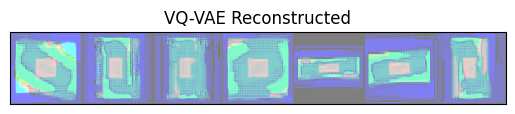

In [49]:
latent = vqae.pre_quantization_conv(latent_centers)
embedding_loss, latent, perplexity, _ = vqae.vector_quantization(latent)
x_hat = vqae.decoder(latent)

def show(img, title):
    npimg = img.numpy()
    fig = plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    fig.axes.set_title(title)
plt.figure()  # Create a new plot
show(torchvision.utils.make_grid(x_hat.cpu().data) + 0.5, "VQ-VAE Reconstructed")
plt.savefig(f"../results/recon_img/MARL_{curr_data}_{cluster_count}cluster_center_recon.png", bbox_inches='tight')



In [50]:
latent.shape

torch.Size([7, 64, 28, 28])

In [51]:
valid_recon = vqae.pre_quantization_conv(latent_centers)
valid_recon.shape

torch.Size([7, 64, 28, 28])

In [52]:
valid_recon[0].shape

torch.Size([64, 28, 28])